# Animated scenes

Nine short scenes, each showing one thing this library does while a parameter sweeps.

The first four are the same four that [NuOscProbExact's notebook 19](https://github.com/mbustama/NuOscProbExact/blob/main/notebooks/19_animations.ipynb)
draws, computed here with Mag$\nu$s so that the two can be read side by side. The five after
them have no counterpart there, because each animates something a closed-form slab code does
not have: a refinement ladder deciding it has converged, a front that travels, an observable
that is an average rather than a value, and a Hamiltonian that genuinely varies along the path.

Rendering them as animations is expensive, so this notebook draws **stills**, as filmstrips,
and leaves the animation to an opt-in switch at the end. The full procedure, its measured
cost, and the traps worth knowing are all at the bottom.

Two things that belong with the *method* rather than with the physics -- what the truncation
order buys, and which engine the dispatcher picks -- are not animated at all. They are single
comparisons rather than sweeps, and they live in
[notebook 24](24_magnus_performance.ipynb).

In [1]:
# The figures are set through LaTeX where one is available; where it is not,
# matplotlib's own mathtext renders the labels instead.  Same numbers either way.
import shutil

import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = shutil.which('latex') is not None

In [2]:
import os

import numpy as np
import matplotlib.pyplot as plt

# Mag(nu)s is imported as an installed package -- from the repository root,
# 'pip install -e .' (add [plot] for magnus.plotting). No sys.path juggling.
import magnus.oscprob as oscprob
import magnus.matter as matter
import magnus.earth as earth
import magnus.globaldefs as gd

# The repository `matplotlibrc` is tuned for single-panel paper figures at
# 5 x 4.75 inches: it sets `axes.labelsize` to 25 and the tick labels to 23,
# ABSOLUTELY rather than relative to `font.size`.  Setting `font.size` here
# therefore moves nothing, and on the wide multi-panel figures below those
# sizes make an axis label render larger than the title above it.  Every size
# used here is restated explicitly, smallest to largest: ticks, labels, title.
plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 13, 'legend.frameon': False,
                     'axes.labelsize': 15, 'axes.titlesize': 15,
                     'xtick.labelsize': 13, 'ytick.labelsize': 13,
                     'legend.fontsize': 12,
                     # Axes end exactly at the data: no dead margin left or right
                     # of any curve, which is the house rule everywhere here.
                     'axes.xmargin': 0.0, 'axes.ymargin': 0.0})

OSC = gd.load_nufit_params('NuFIT 6.1', 'NO')
KM = gd.CONV_KM_TO_INV_EV                 # multiply a length in km to get eV^-1
GEV, MEV = gd.UNIT_GEV, gd.UNIT_MEV

ACCENT, MARK, MUTED = '#1d4ed8', '#dc2626', '#94a3b8'

# `matplotlibrc` sets text.usetex, so every label goes through LaTeX. In LaTeX's
# text mode `>` and `<` render as inverted punctuation -- a title reading
# "rtol -> magnus" comes out with an upside-down question mark in it. Use $\to$,
# in math mode, or avoid the characters. This cost one rendered clip.
ARROW = r'$\to$'


# The one call that returns a whole map, and the idiom is not the obvious one.
# Mag(nu)s pairs energy and baseline ELEMENTWISE -- two 1-D arrays of length n
# give n probabilities, not an n x n grid -- so a map is a flattened meshgrid
# handed over in a single call, rather than a Hamiltonian stack broadcast
# against baselines the way NuOscProbExact does it. Same result, and the same
# one call; a different route to it.
def constant_density_map(energies, baselines, rho, osc=None, nu_i=None, nu_f=None,
                         **kw):
    """P over the (energy, baseline) grid, in one call."""
    ee, ll = np.meshgrid(energies, baselines, indexing='ij')
    flat = np.asarray(oscprob.osc_prob_3nu_matter_constant_density(
        ee.ravel(), ll.ravel(), rho, **(osc or OSC),
        density_matter_is_in_g_per_cm3=True,
        nu_i=gd.NUMU if nu_i is None else nu_i,
        nu_f=gd.NUE if nu_f is None else nu_f, **kw))
    return flat.reshape(ee.shape)


def filmstrip(n_panels, height=3.1, width_each=3.4, ratios=None):
    """A row of panels, which is how a sweep is shown without animating it."""
    return plt.subplots(1, n_panels, figsize=(width_each*n_panels, height),
                        gridspec_kw=None if ratios is None
                        else {'width_ratios': ratios})


print('Nine scenes: four shared with NuOscProbExact, five particular to this library.')

Nine scenes: four shared with NuOscProbExact, five particular to this library.


# Part I --- the four scenes NuOscProbExact also draws

Same four sweeps, same layout, computed with Mag$\nu$s. Reading them beside the originals is
the point: where the two libraries differ, the difference shows up in how the frame is
computed rather than in what it contains.

## 1. The CP phase

An oscillogram of $P_{\mu e}$ in matter, recomputed at each phase, beside the bi-probability
ellipse --- which is the locus traced *by* the phase, so the ellipse is drawn once and the
marker says where on it the map currently sits.

Each map is 200 x 200 = 40 000 probabilities in **one** call, in about 0.09 s. The mechanism
is not the one NuOscProbExact uses: there, a stack of Hamiltonians broadcasts against a row of
baselines; here, energy and baseline pair elementwise, so the grid is flattened, handed over
once, and reshaped.

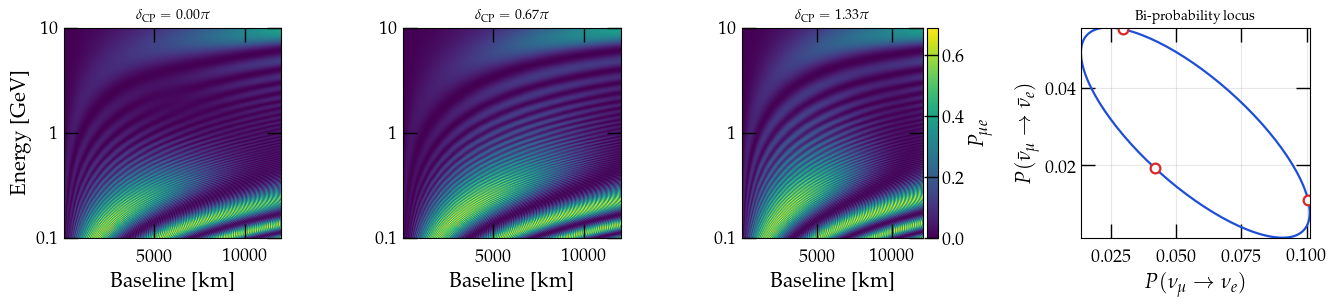

In [3]:
GRID_CP = 200
energies_cp = np.logspace(-1.0, 1.0, GRID_CP)*GEV
baselines_cp = np.linspace(50.0, 12000.0, GRID_CP)*KM
EXTENT_CP = [50.0, 12000.0, -1.0, 1.0]


def oscillogram_cp(dcp):
    return constant_density_map(energies_cp, baselines_cp,
                                gd.DENSITY_MATTER_CRUST_G_PER_CM3,
                                osc=dict(OSC, dCP=dcp))


def ellipse_point(dcp, energy=0.8*GEV, baseline=1300.0*KM):
    """One (P, Pbar) pair. Antineutrinos need the flag, not a hand-built H."""
    p = float(np.asarray(oscprob.osc_prob_3nu_matter_constant_density(
        energy, baseline, gd.DENSITY_MATTER_CRUST_G_PER_CM3,
        **dict(OSC, dCP=dcp), density_matter_is_in_g_per_cm3=True,
        nu_i=gd.NUMU, nu_f=gd.NUE)))
    pbar = float(np.asarray(oscprob.osc_prob_3nu_matter_constant_density(
        energy, baseline, gd.DENSITY_MATTER_CRUST_G_PER_CM3,
        **dict(OSC, dCP=dcp), density_matter_is_in_g_per_cm3=True,
        nu_i=gd.NUMU, nu_f=gd.NUE, nubar=True)))
    return p, pbar


PHASES_SHOWN = [0.0, 2.0*np.pi/3.0, 4.0*np.pi/3.0]
locus_cp = np.array([ellipse_point(d)
                     for d in np.linspace(0.0, 2.0*np.pi, 160)])
# One color scale for the whole sweep. Taking it from a single frame lets the
# others clip silently, and clipping reads as structure rather than saturation.
CEIL_CP = max(float(oscillogram_cp(d).max())
              for d in np.linspace(0.0, 2.0*np.pi, 8, endpoint=False))


def style_map_cp(ax):
    ax.set_xlabel('Baseline [km]')
    ax.set_xlim(EXTENT_CP[0], EXTENT_CP[1])
    ax.set_ylim(EXTENT_CP[2], EXTENT_CP[3])
    ax.set_yticks([-1, 0, 1])
    ax.set_yticklabels(['0.1', '1', '10'])
    ax.grid(False)


fig, axes = filmstrip(4, height=3.3, ratios=[1, 1, 1, 1.05])
for ax, dcp in zip(axes[:3], PHASES_SHOWN):
    im = ax.imshow(oscillogram_cp(dcp), origin='lower', aspect='auto',
                   cmap='viridis', vmin=0.0, vmax=CEIL_CP, extent=EXTENT_CP)
    ax.set_title(r'$\delta_{\rm CP} = %.2f\pi$' % (dcp/np.pi), fontsize=10)
    style_map_cp(ax)
axes[0].set_ylabel('Energy [GeV]')
fig.colorbar(im, ax=axes[2], pad=0.02).set_label(r'$P_{\mu e}$')

ax = axes[3]
ax.plot(locus_cp[:, 0], locus_cp[:, 1], color=ACCENT, lw=1.6)
for dcp in PHASES_SHOWN:
    p, pbar = ellipse_point(dcp)
    ax.plot([p], [pbar], 'o', ms=7, color=MARK, mfc='white', mew=1.6)
ax.set_xlabel(r'$P(\nu_\mu \to \nu_e)$')
ax.set_ylabel(r'$P(\bar\nu_\mu \to \bar\nu_e)$')
ax.set_title('Bi-probability locus', fontsize=10)
fig.tight_layout(pad=1.2)

## 2. A sterile state

Four flavors, in matter of constant density so the whole map is again one call. The sterile
state feels neither the charged- nor the neutral-current potential, so $V_{\rm NC}$ stops
canceling between the flavors and sits on the sterile entry --- which is what places the
resonance that moves across the frame as $\Delta m^2_{41}$ sweeps.

**That term is the one this library got wrong and fixed.** It comes from
`matter.matter_potential_projector`, and omitting it costs 0.29 in probability on an Earth
chord while being flat in tolerance, so no amount of refinement reveals it.

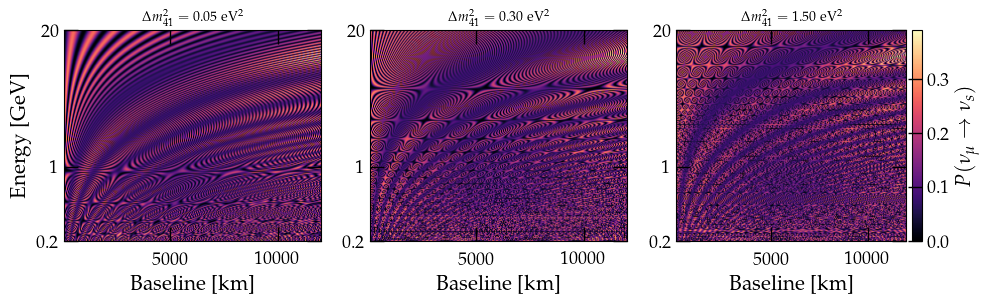

In [4]:
GRID_ST = 260                     # the map is the picture, so it is worth resolving
energies_st = np.logspace(-0.7, 1.3, GRID_ST)*GEV
baselines_st = np.linspace(50.0, 12000.0, GRID_ST)*KM
EXTENT_ST = [50.0, 12000.0, -0.7, 1.3]
STERILE = dict(s14=np.sqrt(0.10), s24=np.sqrt(0.10), s34=0.0, d14=0.0, d24=0.0)


def oscillogram_sterile(d41):
    ee, ll = np.meshgrid(energies_st, baselines_st, indexing='ij')
    flat = np.asarray(oscprob.osc_prob_4nu_matter_constant_density(
        ee.ravel(), ll.ravel(), gd.DENSITY_MATTER_CRUST_G_PER_CM3,
        **OSC, **STERILE, D41=d41, density_matter_is_in_g_per_cm3=True,
        nu_i=gd.NUMU, nu_f=gd.NUS1))
    return flat.reshape(ee.shape)


def style_map_st(ax):
    ax.set_xlabel('Baseline [km]')
    ax.set_xlim(EXTENT_ST[0], EXTENT_ST[1])
    ax.set_ylim(EXTENT_ST[2], EXTENT_ST[3])
    ax.set_yticks([-0.7, 0.0, 1.3])
    ax.set_yticklabels(['0.2', '1', '20'])
    ax.grid(False)


SPLITTINGS_SHOWN = [0.05, 0.30, 1.50]
CEIL_ST = max(float(oscillogram_sterile(d).max()) for d in SPLITTINGS_SHOWN)

fig, axes = filmstrip(3, height=3.3, ratios=[1, 1, 1.08])
for ax, d41 in zip(axes, SPLITTINGS_SHOWN):
    im = ax.imshow(oscillogram_sterile(d41), origin='lower', aspect='auto',
                   cmap='magma', vmin=0.0, vmax=CEIL_ST, extent=EXTENT_ST,
                   interpolation='bilinear')
    ax.set_title(r'$\Delta m^2_{41} = %.2f$ eV$^2$' % d41, fontsize=10)
    style_map_st(ax)
axes[0].set_ylabel('Energy [GeV]')
fig.colorbar(im, ax=axes[2], pad=0.02).set_label(r'$P(\nu_\mu \to \nu_s)$')
fig.tight_layout(pad=1.2)

## 3. Through the Earth

**A detector sits at the South Pole and the arrival direction swings**, which is the way the
measurement is actually made: the detector does not move, the sky does. As $\cos\theta_z$ goes
from $-1$ to grazing, the chord reaching that fixed point sweeps across the Earth's interior
and crosses fewer and fewer of the layers.

The cross-section carries **every PREM boundary**, nine of them, shaded by density --- the
inner core, the outer core, and the seven shells above it. The chord and the layer crossings
are rebuilt each frame; the energies along it are one call.

/home/mbustamante/Research/magnus/src/magnus/oscprob.py:4389: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi, over by up to a factor of ten). This is a statement about the slab width, not about the answer: it reports that a sufficient condition for convergence was not met somewhere, and the error may be anywhere from negligible to large. To act on it, use more (narrower) slabs -- request a smaller rtol/atol, or raise n_slabs; raising magnus_exp_order will not help in this regime. If the profile has a density jump or a kink, pass t_breakpoints there as well: a slab straddling one is not fixed by any number of slabs. Do NOT assume the adaptive refinement has already taken care of it -- measured on a sawtooth density with rtol=atol=1e-3 explicitly requested, the refinement ran and the answer was still 7.5e-03, seven times outside the tolerance asked for. Shown once per session.
  U = magnus.evolution_operator

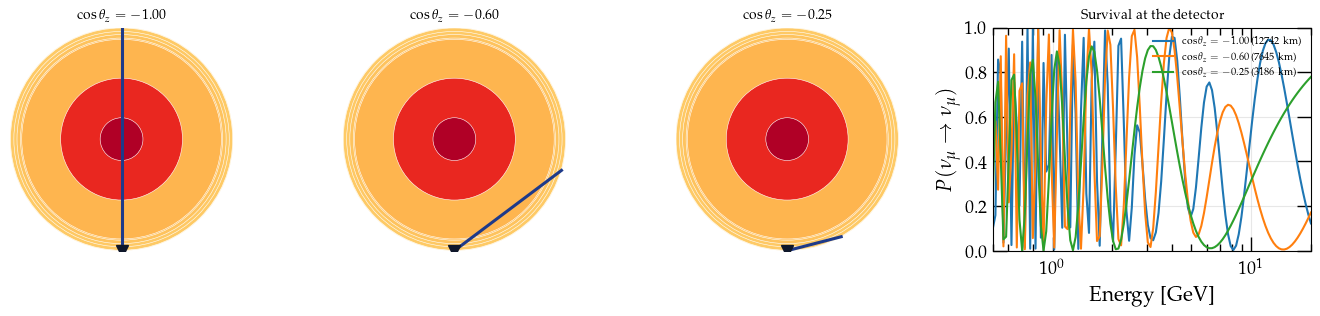

In [5]:
from matplotlib.patches import Circle

R_EARTH = gd.EARTH_RADIUS
DETECTOR = np.array([0.0, -R_EARTH])          # the South Pole, and it stays put
energies_earth = np.logspace(np.log10(0.5), np.log10(20.0), 120)*GEV
ANGLES_SHOWN = [-1.0, -0.6, -0.25]


def chord_entry(costhz):
    """Where a neutrino with this zenith angle enters, to reach the detector.

    The chord subtends a central angle of 2 arcsin(-cos theta_z), so the entry
    point is the detector rotated by that much around the center.
    """
    alpha = 2.0*np.arcsin(min(-costhz, 1.0))
    phi = -0.5*np.pi + alpha
    return np.array([R_EARTH*np.cos(phi), R_EARTH*np.sin(phi)])


def earth_curve(costhz):
    chord = earth.distance_traveled_inside_earth(costhz)
    return chord, np.asarray(oscprob.osc_prob_3nu_earth(
        energies_earth, costhz=costhz, L=chord*KM, **OSC,
        nu_i=gd.NUMU, nu_f=gd.NUMU))


def draw_earth(ax):
    """Every PREM shell, brightest at the core, with no frame around it."""
    edges = np.concatenate([np.asarray(earth.PREM_BOUNDARIES), [R_EARTH]])
    rho = np.asarray(earth.density_matter_func_prem(
        np.clip(edges - 1.0, 0.0, R_EARTH)))
    norm = (rho - rho.min())/(rho.max() - rho.min())
    for r, shade in sorted(zip(edges, norm), reverse=True):
        ax.add_patch(Circle((0, 0), r, facecolor=plt.cm.YlOrRd(0.15 + 0.75*shade),
                            edgecolor='white', lw=0.4, zorder=1))
    ax.set_xlim(-R_EARTH, R_EARTH)
    ax.set_ylim(-R_EARTH, R_EARTH)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    for side in ('top', 'bottom', 'left', 'right'):
        ax.spines[side].set_visible(False)          # no bounding box
    ax.plot(*DETECTOR, marker='v', ms=9, color='#0f172a', zorder=5)


fig, axes = filmstrip(4, height=3.4, ratios=[1, 1, 1, 1.25])
for ax, cz in zip(axes[:3], ANGLES_SHOWN):
    draw_earth(ax)
    entry = chord_entry(cz)
    ax.plot([entry[0], DETECTOR[0]], [entry[1], DETECTOR[1]],
            color='#1e3a8a', lw=2.2, zorder=4)
    ax.set_title(r'$\cos\theta_z = %+.2f$' % cz, fontsize=10)

ax = axes[3]
for cz in ANGLES_SHOWN:
    chord, prob = earth_curve(cz)
    ax.semilogx(energies_earth/GEV, prob, lw=1.5,
                label=r'$\cos\theta_z = %+.2f$  (%.0f km)' % (cz, chord))
ax.set_xlabel('Energy [GeV]')
ax.set_ylabel(r'$P(\nu_\mu \to \nu_\mu)$')
ax.set_title('Survival at the detector', fontsize=10)
ax.set_xlim(energies_earth[0]/GEV, energies_earth[-1]/GEV)
ax.set_ylim(0.0, 1.0)
ax.legend(fontsize=7.5)
fig.tight_layout(pad=1.2)

## 4. Cutting a profile into slabs

The one approximation the method makes. Within a slab nothing is approximated --- the
expansion is exact for a constant Hamiltonian --- so the only question is how finely a profile
that really varies is sliced.

**Two things had to be forced to make this scene show anything.** Left to itself,
`strategy='auto'` does not use the slab ladder on a smooth exponential at all: it takes the
adiabatic route, and the answer is then *identical* at 2, 8 and 40 slabs. The sweep below
therefore passes `strategy='magnus'` and pins the slab count at both ends, which is the only
way to watch the discretization converge rather than watch the dispatcher avoid it.

/home/mbustamante/Research/magnus/src/magnus/oscprob.py:6250: ToleranceNotAchievedWarning: osc_prob: requested tolerance not achieved (max_n_slabs reached), with no two levels to compare, so convergence could not be verified by successive refinement and the returned probabilities may be inaccurate. Raise max_n_slabs. This can happen for very large accumulated phases, e.g., low-energy neutrinos over very long baselines, or eV-scale sterile splittings over Earth-crossing baselines. If the profile has a density jump or a kink, pass t_breakpoints there as well -- a slab straddling one is never fixed by more slabs. Shown once per session.
  P = osc_prob(H_at_energy(enu), L0, baseline, **osc_prob_kwargs)
/home/mbustamante/Research/magnus/src/magnus/magnus.py:1796: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi, over by up to a factor of ten). This is a statement about the slab width, not about the answer: it rep

Converged reference (600 slabs): P = 0.09122705
One slab is off by 8.73e-04; forty slabs by 6.72e-08.


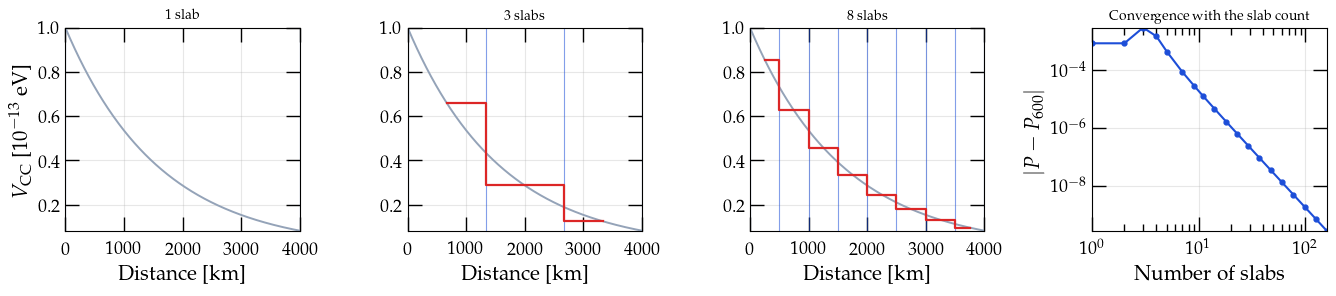

In [6]:
PER_NE = matter.VCC_func(l=0.0, num_density_e_func=lambda l: 1.0)
L_SLAB = 4000.0*KM


def ne_expo(l):
    """A smoothly falling profile: the case a slab count actually has to resolve."""
    return (1.0e-13*np.exp(-2.5*np.asarray(l, dtype=float)/L_SLAB))/PER_NE


def slabbed(n_slabs):
    return float(np.asarray(oscprob.osc_prob_matter_std_potential(
        3, ne_expo, 1.0*GEV, L_SLAB, OSC, L0=0.0,
        density_is_of_number_of_electrons=True, strategy='magnus',
        n_slabs=n_slabs, min_n_slabs=n_slabs, max_n_slabs=max(n_slabs, 2),
        nu_i=gd.NUMU, nu_f=gd.NUE, rtol=1.0e-13, atol=1.0e-15)))


SLABS_SHOWN = [1, 3, 8]
P_CONVERGED = slabbed(600)
ell = np.linspace(0.0, L_SLAB, 400)
vcc_profile = np.asarray(ne_expo(ell))*PER_NE

fig, axes = filmstrip(4, height=3.2)
for ax, n in zip(axes[:3], SLABS_SHOWN):
    ax.plot(ell/KM, vcc_profile/1.0e-13, color=MUTED, lw=1.4)
    edges = np.linspace(0.0, L_SLAB, n + 1)
    mid = 0.5*(edges[:-1] + edges[1:])
    for e in edges:
        ax.axvline(e/KM, color=ACCENT, lw=0.8, alpha=0.55)
    ax.step(mid/KM, np.asarray(ne_expo(mid))*PER_NE/1.0e-13, where='mid',
            color=MARK, lw=1.6)
    ax.set_title('%d slab%s' % (n, '' if n == 1 else 's'), fontsize=10)
    ax.set_xlabel('Distance [km]')
    ax.set_xlim(0.0, L_SLAB/KM)
axes[0].set_ylabel(r'$V_{\rm CC}$  [$10^{-13}$ eV]')

ax = axes[3]
counts = np.unique(np.round(np.logspace(0, 2.2, 22)).astype(int))
errors = [max(abs(slabbed(int(n)) - P_CONVERGED), 1.0e-16) for n in counts]
ax.loglog(counts, errors, '-o', ms=3.5, color=ACCENT)
ax.set_xlabel('Number of slabs')
ax.set_ylabel(r'$|P - P_{600}|$')
ax.set_title('Convergence with the slab count', fontsize=10)
ax.set_xlim(counts[0], counts[-1])
fig.tight_layout(pad=1.2)

print('Converged reference (600 slabs): P = %.8f' % P_CONVERGED)
print('One slab is off by %.2e; forty slabs by %.2e.'
      % (abs(slabbed(1) - P_CONVERGED), abs(slabbed(40) - P_CONVERGED)))

# Part II --- five scenes with no counterpart

Each of these animates something a closed-form slab code does not have: a ladder that decides
when it has converged, a front that travels, an observable that is an average rather than a
value, and Hamiltonians that vary along the path.

## 5. The refinement ladder, deciding

A tolerance is not met by raising the order --- it is met by **adding slabs**, and the ladder
does that on its own until two successive refinements agree to within what was asked. The
interesting rows are the ones where it stops being able to: past a point it hits its ceiling
and says so with a warning rather than returning a silently wrong number.

This one is a table rather than a picture, so it is not animated.

Requested   achieved     warned?
  1e-02     2.95e-05     yes
  1e-03     4.67e-06     yes
  1e-04     8.98e-07     yes
  1e-05     1.65e-07     yes
  1e-06     6.37e-09     yes
  1e-07     1.26e-09     yes
  1e-08     4.77e-11     yes
  1e-09     8.42e-12     yes
  1e-10     6.04e-13     yes
  1e-11     1.24e-12     yes


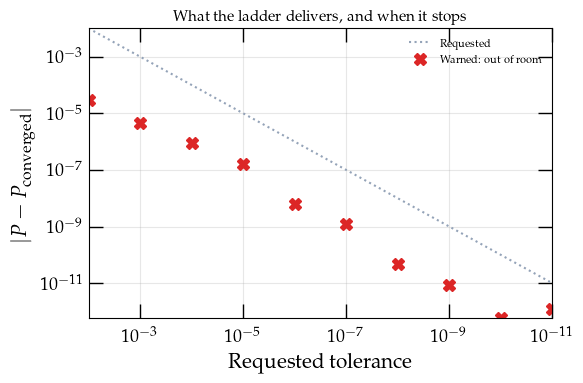

In [7]:
import warnings as _warnings

TOLERANCES = np.logspace(-2, -11, 10)


def laddered(rtol):
    """Let the ladder choose, and report whether it ran out of room."""
    with _warnings.catch_warnings(record=True) as caught:
        _warnings.simplefilter('always')
        p = float(np.asarray(oscprob.osc_prob_matter_std_potential(
            3, ne_expo, 1.0*GEV, L_SLAB, OSC, L0=0.0,
            density_is_of_number_of_electrons=True, strategy='magnus',
            rtol=rtol, atol=rtol*1.0e-2, nu_i=gd.NUMU, nu_f=gd.NUE)))
        # `certified` is filled in by the hybrid dispatcher, not by the bare
        # ladder, so on strategy='magnus' it is always None and cannot be the
        # signal. What the ladder itself reports is the warning.
        warned = any('Tolerance' in w.category.__name__ or
                     'Convergence' in w.category.__name__ for w in caught)
    return p, warned


results = [laddered(t) for t in TOLERANCES]
errs = [max(abs(p - P_CONVERGED), 1.0e-17) for p, _ in results]

fig, ax = plt.subplots(figsize=(6.0, 4.0))
ok = [(t, e) for t, e, (_, w) in zip(TOLERANCES, errs, results) if not w]
bad = [(t, e) for t, e, (_, w) in zip(TOLERANCES, errs, results) if w]
ax.loglog(TOLERANCES, TOLERANCES, ls=':', color=MUTED, label='Requested')
if ok:
    ax.loglog(*zip(*ok), 'o', ms=7, color=ACCENT, mfc='white', mew=1.6,
              label='Converged silently')
if bad:
    ax.loglog(*zip(*bad), 'X', ms=8, color=MARK, label='Warned: out of room')
ax.set_xlabel('Requested tolerance')
ax.set_ylabel(r'$|P - P_{\rm converged}|$')
ax.set_title('What the ladder delivers, and when it stops', fontsize=11)
ax.set_xlim(TOLERANCES[0], TOLERANCES[-1])
ax.legend(fontsize=8)
fig.tight_layout(pad=1.0)

print('Requested   achieved     warned?')
for tol, (p, w) in zip(TOLERANCES, results):
    print('  %.0e     %.2e     %s' % (tol, abs(p - P_CONVERGED), 'yes' if w else 'no'))

## 6. A supernova shock, sweeping outward

The forward shock moves out through the star, and as it crosses the region where the
$\Delta m^2_{31}$ resonance sits it changes **how adiabatically that level crossing is
made** --- which moves the conversion probability itself rather than its phase. Averaging
cannot remove it.

Every frame is a different Hamiltonian along the whole ray, and the front is declared through
`t_breakpoints` at each position, because no fixed grid resolves a discontinuity it was not
told about.

The resulting trace looks ragged, and that is the answer rather than a defect in it. Between
neighboring front positions the survival probability really does swing by tenths, and
checking that takes more care than it looks: comparing a coarse sampling against a finer one
proves nothing if both are under-resolved, because then the two agree about a number neither
of them has right. Driven to convergence instead --- $102\,400$ slabs, where the answer is
stable to $8 \times 10^{-6}$ --- forty points spaced $103$ km apart across the busy stretch
still step by $0.142$ on average, and still span $0.228$ to $0.570$. The structure is
physical, and finer than a hundred kilometers in front position.

It is drawn as markers on a faint line for that reason: a confident curve through these
points would claim a resolution that no affordable sampling has. The points themselves are
trustworthy --- against those converged values the settings used here are worst-case
$3.6 \times 10^{-3}$ over the whole sweep, which is well under the width of the marker.

/home/mbustamante/Research/magnus/src/magnus/magnus.py:1796: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi, over by more than a factor of ten). This is a statement about the slab width, not about the answer: it reports that a sufficient condition for convergence was not met somewhere, and the error may be anywhere from negligible to large. To act on it, use more (narrower) slabs -- request a smaller rtol/atol, or raise n_slabs; raising magnus_exp_order will not help in this regime. If the profile has a density jump or a kink, pass t_breakpoints there as well: a slab straddling one is not fixed by any number of slabs. Do NOT assume the adaptive refinement has already taken care of it -- measured on a sawtooth density with rtol=atol=1e-3 explicitly requested, the refinement ran and the answer was still 7.5e-03, seven times outside the tolerance asked for. Shown once per session.
  return evolution_operators

P_ee swings from 0.0274 to 0.4902 as the front sweeps outward.


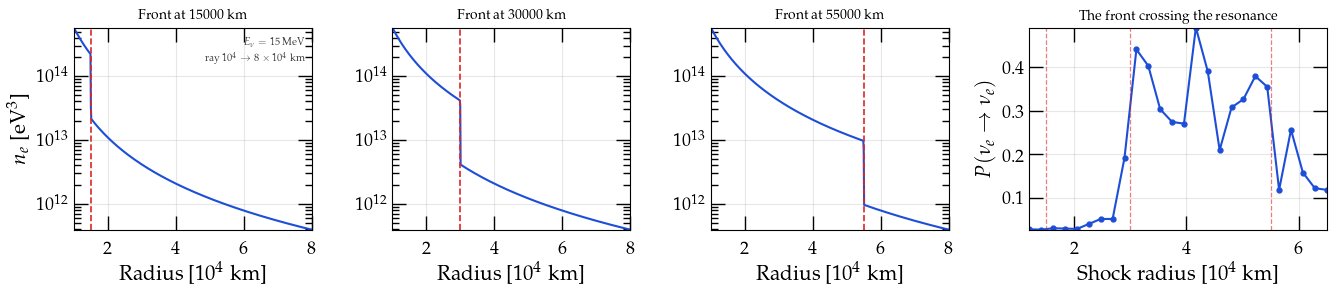

In [8]:
MEAN_NUCLEON = 0.5*(gd.MASS_PROTON + gd.MASS_NEUTRON)
R0_SHOCK, R1_SHOCK = 1.0e4, 8.0e4          # the ray, in km
E_SHOCK = 15.0*MEV
W_SHOCK = 1.0e-3                            # front width, as a fraction of the ray
SHOCK_NOTE = (r'$E_\nu = 15$ MeV' '\n'
              r'ray $10^4 \to 8 \times 10^4$ km')


def smoothstep(u):
    u = np.clip(np.asarray(u, dtype=float), 0.0, 1.0)
    return u*u*(3.0 - 2.0*u)


def ne_shock(r_front_km):
    """Electron density along the ray, for a front at this radius."""
    w_km = W_SHOCK*(R1_SHOCK - R0_SHOCK)

    def ne(l):
        r = np.asarray(l, dtype=float)/KM
        rho = 1.0e14*r**(-2.4)
        shocked = smoothstep((r_front_km + 0.5*w_km - r)/w_km)
        out = rho*(1.0 + shocked*9.0)*gd.UNIT_G_PER_CM3/MEAN_NUCLEON*0.5
        return out[()] if np.ndim(out) == 0 else out
    return ne


def shock_probability(r_front_km):
    w_km = W_SHOCK*(R1_SHOCK - R0_SHOCK)
    edges = np.array([R0_SHOCK, r_front_km - 0.5*w_km,
                      r_front_km + 0.5*w_km, R1_SHOCK])*KM
    return float(np.asarray(oscprob.osc_prob_matter_std_potential(
        3, ne_shock(r_front_km), E_SHOCK, R1_SHOCK*KM, OSC, L0=R0_SHOCK*KM,
        density_is_of_number_of_electrons=True,
        t_breakpoints=np.unique(edges), nu_i=gd.NUE, nu_f=gd.NUE)))


FRONTS_SHOWN = [1.5e4, 3.0e4, 5.5e4]
# Linear in radius, not logarithmic: on a log axis the decade labels crowd into
# each other over this range and the front's motion is squeezed into a corner.
rr = np.linspace(R0_SHOCK, R1_SHOCK, 600)

fig, axes = filmstrip(4, height=3.2, ratios=[1, 1, 1, 1.25])
for k, (ax, rf) in enumerate(zip(axes[:3], FRONTS_SHOWN)):
    ax.semilogy(rr/1.0e4, np.asarray(ne_shock(rf)(rr*KM)), color=ACCENT, lw=1.5)
    ax.axvline(rf/1.0e4, color=MARK, ls='--', lw=1.2)
    ax.set_title('Front at %.0f km' % rf, fontsize=10)
    ax.set_xlabel(r'Radius [$10^4$ km]')
    ax.set_xlim(R0_SHOCK/1.0e4, R1_SHOCK/1.0e4)
    if k == 0:
        ax.text(0.97, 0.95, SHOCK_NOTE, transform=ax.transAxes, ha='right',
                va='top', fontsize=7.5, color='0.25', linespacing=1.4)
axes[0].set_ylabel(r'$n_e$  [eV$^3$]')

ax = axes[3]
fronts = np.linspace(1.2e4, 6.5e4, 26)
probs = [shock_probability(r) for r in fronts]
ax.plot(fronts/1.0e4, probs, '-o', ms=3.5, color=ACCENT)
for rf in FRONTS_SHOWN:
    ax.axvline(rf/1.0e4, color=MARK, ls='--', lw=0.9, alpha=0.6)
ax.set_xlabel(r'Shock radius [$10^4$ km]')
ax.set_ylabel(r'$P(\nu_e \to \nu_e)$')
ax.set_title('The front crossing the resonance', fontsize=10)
ax.set_xlim(fronts[0]/1.0e4, fronts[-1]/1.0e4)
fig.tight_layout(pad=1.2)

print('P_ee swings from %.4f to %.4f as the front sweeps outward.'
      % (min(probs), max(probs)))

## 7. The average, emerging

Over the ray out of the Sun a few-MeV neutrino accumulates thousands of radians of phase, so
the instantaneous survival probability is neither measurable nor stable. What an experiment
measures is the **phase-averaged** probability, and `average=True` returns it directly.

The other way to get it is to propagate anyway and average many evaluations over a window in
energy. It converges slowly, and that is the honest result: the window mean is a Monte-Carlo
estimate of an average over a phase that turns over thousands of times, so its error falls
only as $1/\sqrt{N}$. This one costs about a minute per point, so it is a still rather than a
clip.

Window          worst gap to average=True
  +/-   2%,  9 samples   0.1817
  +/-   6%, 15 samples   0.1039
  +/-  10%, 21 samples   0.0779


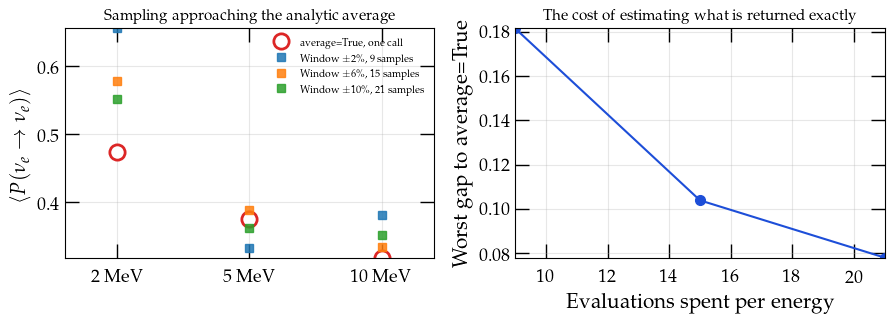

In [9]:
SOLAR_TABLE = '../docs/dev/adversarial_batteries/bs05_agsop.dat'
_rows = []
with open(SOLAR_TABLE) as fh:
    for line in fh:
        f = line.split()
        if len(f) == 12:
            try:
                _rows.append([float(x) for x in f])
            except ValueError:
                continue
_solar = np.array(_rows)
_mean_nucleon = 0.5*(gd.MASS_PROTON + gd.MASS_NEUTRON)
_ne_solar = _solar[:, 3]*gd.UNIT_G_PER_CM3/_mean_nucleon*(0.5*(1.0 + _solar[:, 6]))
_x_solar = _solar[:, 1]*gd.SUN_RADIUS*gd.UNIT_KM
_log_ne = np.log(_ne_solar)
R_SUN_AVG = float(_x_solar[-1])


def ne_sun(l):
    xs = np.clip(np.asarray(l, dtype=float), _x_solar[0], _x_solar[-1])
    out = np.exp(np.interp(xs, _x_solar, _log_ne))
    return out[()] if np.ndim(out) == 0 else out


E_AVG = np.array([2.0, 5.0, 10.0])*MEV
P_AVG_EXACT = np.asarray(oscprob.osc_prob_matter_std_potential(
    3, ne_sun, E_AVG, R_SUN_AVG, OSC, L0=0.0,
    density_is_of_number_of_electrons=True, nu_i=gd.NUE, nu_f=gd.NUE,
    average=True))


def window_mean(half_width, n_samples):
    offs = np.linspace(-half_width, half_width, n_samples)
    with _warnings.catch_warnings():
        _warnings.simplefilter('ignore')
        return np.array([float(np.mean(np.asarray(
            oscprob.osc_prob_matter_std_potential(
                3, ne_sun, e*(1.0 + offs), R_SUN_AVG, OSC, L0=0.0,
                density_is_of_number_of_electrons=True,
                nu_i=gd.NUE, nu_f=gd.NUE)))) for e in E_AVG])


WINDOWS = [(0.02, 9), (0.06, 15), (0.10, 21)]
means = [window_mean(hw, n) for hw, n in WINDOWS]
gaps = [float(np.max(np.abs(m - P_AVG_EXACT))) for m in means]

fig, axes = filmstrip(2, height=3.4, width_each=4.6)
ax = axes[0]
idx = np.arange(len(E_AVG))
ax.plot(idx, P_AVG_EXACT, 'o', ms=11, color=MARK, mfc='white', mew=2.0,
        label='average=True, one call')
for (hw, n), m in zip(WINDOWS, means):
    ax.plot(idx, m, 's', ms=6, alpha=0.85,
            label=r'Window $\pm%.0f\%%$, %d samples' % (100*hw, n))
ax.set_xticks(idx)
ax.set_xticklabels(['%.0f MeV' % (e/MEV) for e in E_AVG])
ax.set_xlim(-0.4, len(E_AVG) - 0.6)
ax.set_ylabel(r'$\langle P(\nu_e \to \nu_e)\rangle$')
ax.set_title('Sampling approaching the analytic average', fontsize=11)
ax.legend(fontsize=7.5)

ax = axes[1]
ns = [n for _, n in WINDOWS]
ax.plot(ns, gaps, '-o', ms=7, color=ACCENT)
ax.set_xlabel('Evaluations spent per energy')
ax.set_ylabel('Worst gap to average=True')
ax.set_title('The cost of estimating what is returned exactly', fontsize=11)
ax.set_xlim(ns[0], ns[-1])
fig.tight_layout(pad=1.0)

print('Window          worst gap to average=True')
for (hw, n), g in zip(WINDOWS, gaps):
    print('  +/-%4.0f%%, %2d samples   %.4f' % (100*hw, n, g))

## 8. A Hamiltonian that depends on position

`H_func` is an arbitrary function of position, so a profile can be anything --- including
something with no closed form and no piecewise-constant description at all. Here a density
wave travels along the path: each frame moves its crest, so the Hamiltonian differs at every
point of every frame.

The dashed curve is the profile at rest, drawn once and left there, so that the size of the
change is legible rather than something to be remembered between frames.

Moving the crest through one period changes the probability by up to 0.076.


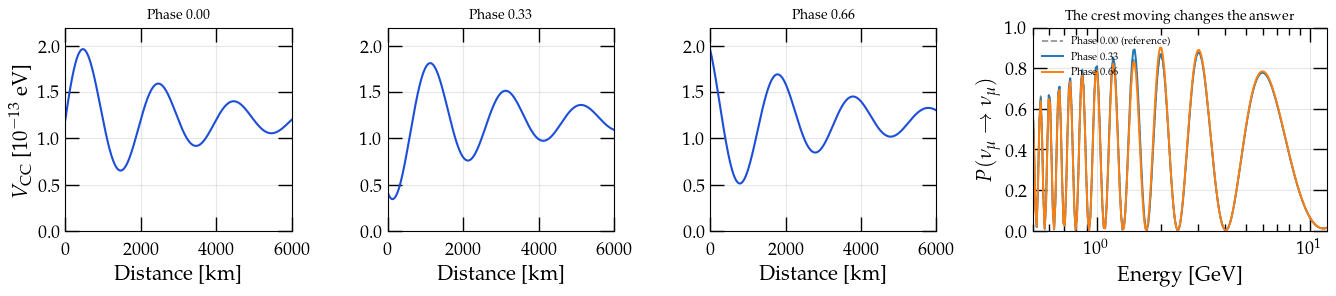

In [10]:
L_WAVE = 6000.0*KM
E_WAVE = np.logspace(np.log10(0.5), np.log10(12.0), 220)*GEV
N_WAVES = 3.0


def ne_wave(phase):
    """A density profile with a traveling crest."""
    def ne(l):
        x = np.asarray(l, dtype=float)/L_WAVE
        env = 1.0 + 0.75*np.sin(2.0*np.pi*(N_WAVES*x - phase))*np.exp(-2.0*x)
        return (1.2e-13*env)/PER_NE
    return ne


def wave_curve(phase):
    with _warnings.catch_warnings():
        _warnings.simplefilter('ignore')
        return np.asarray(oscprob.osc_prob_matter_std_potential(
            3, ne_wave(phase), E_WAVE, L_WAVE, OSC, L0=0.0,
            density_is_of_number_of_electrons=True,
            nu_i=gd.NUMU, nu_f=gd.NUMU))


PHASES_WAVE = [0.0, 0.33, 0.66]
xx = np.linspace(0.0, L_WAVE, 400)
WAVE_REFERENCE = wave_curve(0.0)              # the fixed curve to read against

fig, axes = filmstrip(4, height=3.2, ratios=[1, 1, 1, 1.3])
for ax, ph in zip(axes[:3], PHASES_WAVE):
    ax.plot(xx/KM, np.asarray(ne_wave(ph)(xx))*PER_NE/1.0e-13, color=ACCENT, lw=1.5)
    ax.set_title('Phase %.2f' % ph, fontsize=10)
    ax.set_xlabel('Distance [km]')
    ax.set_xlim(0.0, L_WAVE/KM)
    ax.set_ylim(0.0, 2.2)
axes[0].set_ylabel(r'$V_{\rm CC}$  [$10^{-13}$ eV]')

ax = axes[3]
ax.semilogx(E_WAVE/GEV, WAVE_REFERENCE, color='0.55', ls='--', lw=1.2,
            label='Phase 0.00 (reference)')
for ph in PHASES_WAVE[1:]:
    ax.semilogx(E_WAVE/GEV, wave_curve(ph), lw=1.4, label='Phase %.2f' % ph)
ax.set_xlabel('Energy [GeV]')
ax.set_ylabel(r'$P(\nu_\mu \to \nu_\mu)$')
ax.set_title('The crest moving changes the answer', fontsize=10)
ax.set_xlim(E_WAVE[0]/GEV, E_WAVE[-1]/GEV)
ax.set_ylim(0.0, 1.0)
ax.legend(fontsize=7.5)
fig.tight_layout(pad=1.2)

sweep = np.array([wave_curve(p) for p in np.linspace(0, 1, 5, endpoint=False)])
print('Moving the crest through one period changes the probability by up to %.3f.'
      % float((sweep.max(axis=0) - sweep.min(axis=0)).max()))

## 9. The Sun, with and without NSI

The solar case is the one where Mag$\nu$s returns the *observable* directly, and it is also
where a BSM term is most cleanly read: the standard three-flavor curve is fixed, and the NSI
curve moves away from it as $\varepsilon_{ee}$ grows.

The standard curve is drawn as a fixed reference in every frame. What sweeps is
$\varepsilon_{ee}$, from zero --- where the two curves must coincide, which is the check that
the sweep is doing what it claims --- up to a value large enough to move the MSW transition
visibly.

Both curves are `average=True` on the real BS2005-AGS,OP model, so each frame is the
phase-averaged probability rather than a sampling of it, and each costs well under a second.

At eps_ee = 0 the two curves agree to 0.00e+00, as they must.


At eps_ee = 0.30 they differ by up to 0.031.


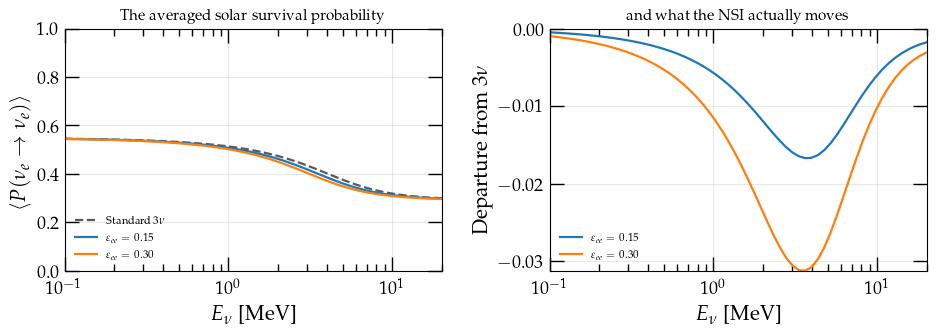

In [11]:
E_NSI = np.logspace(np.log10(0.1), np.log10(20.0), 60)*MEV


def solar_curve(eps_ee, eps_em=0.0):
    """<P_ee> across energy, at this NSI strength. eps = 0 is the standard case."""
    eps = dict(eps_ee=eps_ee, eps_em=eps_em, eps_et=0.0,
               eps_mm=0.0, eps_mt=0.0, eps_tt=0.0)
    with _warnings.catch_warnings():
        _warnings.simplefilter('ignore')
        return np.asarray(oscprob.osc_prob_matter_nsi(
            3, ne_sun, E_NSI, R_SUN_AVG, OSC, eps, L0=0.0,
            density_is_of_number_of_electrons=True,
            nu_i=gd.NUE, nu_f=gd.NUE, average=True))


SOLAR_STANDARD = np.asarray(oscprob.osc_prob_matter_std_potential(
    3, ne_sun, E_NSI, R_SUN_AVG, OSC, L0=0.0,
    density_is_of_number_of_electrons=True, nu_i=gd.NUE, nu_f=gd.NUE,
    average=True))
EPS_SHOWN = [0.0, 0.15, 0.30]

# Two panels, because the departure is a few hundredths: on the probability axis
# alone the curves nearly overlie, and the second panel is what makes the size of
# the effect legible rather than something to be squinted at.
fig, axes = filmstrip(2, height=3.6, width_each=4.8)
ax = axes[0]
ax.semilogx(E_NSI/MEV, SOLAR_STANDARD, color='0.35', ls='--', lw=1.6,
            label=r'Standard 3$\nu$')
for eps in EPS_SHOWN[1:]:
    ax.semilogx(E_NSI/MEV, solar_curve(eps), lw=1.6,
                label=r'$\varepsilon_{ee} = %.2f$' % eps)
ax.set_xlabel(r'$E_\nu$ [MeV]')
ax.set_ylabel(r'$\langle P(\nu_e \to \nu_e)\rangle$')
ax.set_xlim(E_NSI[0]/MEV, E_NSI[-1]/MEV)
ax.set_ylim(0.0, 1.0)
ax.set_title('The averaged solar survival probability', fontsize=11)
ax.legend(fontsize=8, loc='lower left')

ax = axes[1]
for eps in EPS_SHOWN[1:]:
    ax.semilogx(E_NSI/MEV, solar_curve(eps) - SOLAR_STANDARD, lw=1.6,
                label=r'$\varepsilon_{ee} = %.2f$' % eps)
ax.axhline(0.0, color='0.35', ls='--', lw=1.2)
ax.set_xlabel(r'$E_\nu$ [MeV]')
ax.set_ylabel(r'Departure from 3$\nu$')
ax.set_xlim(E_NSI[0]/MEV, E_NSI[-1]/MEV)
ax.set_title('and what the NSI actually moves', fontsize=11)
ax.legend(fontsize=8)
fig.tight_layout(pad=1.2)

print('At eps_ee = 0 the two curves agree to %.2e, as they must.'
      % float(np.max(np.abs(solar_curve(0.0) - SOLAR_STANDARD))))
print('At eps_ee = 0.30 they differ by up to %.3f.'
      % float(np.max(np.abs(solar_curve(0.30) - SOLAR_STANDARD))))

## Rendering them as animations

Six of the nine scenes animate: the CP phase, the sterile state, the Earth, the slab count,
the shock and the traveling crest, plus the Sun with NSI. The ladder and the averaging scenes
do not --- one is a table and the other costs about a minute per point.

The stills above are what this notebook draws by default. Set `RENDER = True` to write the
raw GIFs into `img/raw/`; the shrunk copies committed in `img/` come from those in a second
step. The procedure, its measured cost and the traps are below the cell.

In [12]:
RENDER = False        # set True to write the GIFs
FPS = 20

if RENDER:
    from matplotlib.animation import FuncAnimation, PillowWriter

    # ONE figure size for every scene, and it is not cosmetic: ffmpeg's concat
    # filter refuses clips whose dimensions differ, and scaling them to a common
    # width leaves different heights when the aspect ratios differ.  Two scenes
    # were drawn narrower here and `--join` failed with "Failed to configure
    # output pad" until they matched.
    FIGSIZE, DPI = (10.0, 4.4), 110
    # RAW renders land in img/raw/, which is gitignored; the shrunk copies that
    # tools/make_demo_video.py writes are what belongs in img/ and in the
    # repository.  Writing both to one directory would mean the next render
    # silently overwrote the committed 15 MB set with the 225 MB one.
    OUT = os.path.join('..', 'img', 'raw')
    os.makedirs(OUT, exist_ok=True)

    def heading_of(fig, w_pad=None):
        """A large title, close to the axes, and nothing written underneath.

        `tight_layout` reserves the top strip; the suptitle then sits just above
        the axes rather than floating halfway up the figure.  20 pt is chosen
        against the 15 pt axis labels set at the top of the notebook, so the
        title reads as the title -- with the repository defaults it would be
        smaller than the words under the x axis.

        `w_pad` widens the gutter between panels, which one scene needs: a
        color bar carries its own rotated label, and with the default gutter
        that label and the next panel's y label sit close enough to be read as
        one two-line label rather than two separate ones.
        """
        head = fig.suptitle('', fontsize=20, y=0.975)
        fig.patch.set_facecolor('white')
        # `pad` is a multiple of the font size, and the default 1.08 leaves a
        # visible white band under the x labels at this aspect.  0.8 reclaims
        # it; going much below that starts trimming descenders, and the labels
        # are the one thing that must not be clipped.
        fig.tight_layout(rect=[0, 0.0, 1, 0.93], pad=0.8,
                         **({} if w_pad is None else {'w_pad': w_pad}))
        return head

    def write(fig, update, frames, name):
        anim = FuncAnimation(fig, update, frames=frames, blit=False)
        path = os.path.join(OUT, name)
        anim.save(path, writer=PillowWriter(fps=FPS),
                  savefig_kwargs={'facecolor': 'white'})
        plt.close(fig)
        print('wrote %s (%.1f MB)'
              % (path, os.path.getsize(path)/1024.0/1024.0), flush=True)

    # ---- 1. the CP phase ---------------------------------------------------
    phases = np.linspace(0.0, 2.0*np.pi, 120, endpoint=False)
    fig, (ax_map, ax_ell) = plt.subplots(
        1, 2, figsize=FIGSIZE, dpi=DPI, gridspec_kw={'width_ratios': [1.45, 1.0]})
    image = ax_map.imshow(oscillogram_cp(phases[0]), origin='lower', aspect='auto',
                          cmap='viridis', vmin=0.0, vmax=CEIL_CP, extent=EXTENT_CP)
    style_map_cp(ax_map)
    ax_map.set_ylabel('Energy [GeV]')
    fig.colorbar(image, ax=ax_map, pad=0.02).set_label(r'$P(\nu_\mu \to \nu_e)$')
    ax_ell.plot(locus_cp[:, 0], locus_cp[:, 1], color=ACCENT, lw=1.8)
    dot, = ax_ell.plot([], [], 'o', ms=10, color=MARK, mfc='white', mew=2.0)
    ax_ell.set_xlabel(r'$P(\nu_\mu \to \nu_e)$')
    ax_ell.set_ylabel(r'$P(\bar\nu_\mu \to \bar\nu_e)$')
    ax_ell.set_xlim(locus_cp[:, 0].min(), locus_cp[:, 0].max())
    ax_ell.set_ylim(locus_cp[:, 1].min(), locus_cp[:, 1].max())
    head = heading_of(fig, w_pad=3.5)

    def update_cp(k):
        image.set_data(oscillogram_cp(phases[k]))
        dot.set_data(*[[v] for v in ellipse_point(phases[k])])
        head.set_text(r'The CP phase:  $\delta_{\rm CP} = %.2f\pi$' % (phases[k]/np.pi))
        return image, dot

    write(fig, update_cp, len(phases), 'anim_cp.gif')

    # ---- 2. a sterile state ------------------------------------------------
    splittings = np.logspace(np.log10(0.03), np.log10(2.0), 90)
    fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)
    img_st = ax.imshow(oscillogram_sterile(splittings[0]), origin='lower',
                       aspect='auto', cmap='magma', vmin=0.0, vmax=CEIL_ST,
                       extent=EXTENT_ST, interpolation='bilinear')
    style_map_st(ax)
    ax.set_ylabel('Energy [GeV]')
    fig.colorbar(img_st, ax=ax, pad=0.02).set_label(r'$P(\nu_\mu \to \nu_s)$')
    head = heading_of(fig)

    def update_sterile(k):
        img_st.set_data(oscillogram_sterile(splittings[k]))
        head.set_text(r'A sterile state:  $\Delta m^2_{41} = %.2f$ eV$^2$'
                      % splittings[k])
        return (img_st,)

    write(fig, update_sterile, len(splittings), 'anim_sterile.gif')

    # ---- 3. through the Earth, detector fixed at the South Pole ------------
    angles = np.linspace(-1.0, -0.05, 150)          # slower than the others
    # The sketch is a circle with `set_aspect('equal')`, so its height sets its
    # width and a half-width panel is all it can fill; giving it an equal share
    # of the row only padded it with white.  The curve takes the difference.
    fig, (ax_geo, ax_p) = plt.subplots(
        1, 2, figsize=FIGSIZE, dpi=DPI, gridspec_kw={'width_ratios': [0.72, 1.0]})
    draw_earth(ax_geo)
    path_line, = ax_geo.plot([], [], color='#1e3a8a', lw=2.4, zorder=4)
    curve, = ax_p.semilogx([], [], color=ACCENT, lw=1.8)
    ax_p.set_xlim(energies_earth[0]/GEV, energies_earth[-1]/GEV)
    ax_p.set_ylim(0.0, 1.0)
    ax_p.set_xlabel('Energy [GeV]')
    ax_p.set_ylabel(r'$P(\nu_\mu \to \nu_\mu)$')
    head = heading_of(fig)

    def update_earth(k):
        cz = angles[k]
        chord, prob = earth_curve(cz)
        entry = chord_entry(cz)
        path_line.set_data([entry[0], DETECTOR[0]], [entry[1], DETECTOR[1]])
        curve.set_data(energies_earth/GEV, prob)
        head.set_text(r'Arriving at the South Pole:  $\cos\theta_z = %+.2f$  (%.0f km)'
                      % (cz, chord))
        return path_line, curve

    write(fig, update_earth, len(angles), 'anim_earth.gif')

    # ---- 4. cutting a profile into slabs -----------------------------------
    slab_frames = np.unique(np.round(np.logspace(0, 2.0, 60)).astype(int))
    fig, (ax_prof, ax_err) = plt.subplots(1, 2, figsize=FIGSIZE, dpi=DPI)
    ax_prof.plot(ell/KM, vcc_profile/1.0e-13, color=MUTED, lw=1.5)
    step_line, = ax_prof.step([], [], where='mid', color=MARK, lw=1.8)
    ax_prof.set_xlim(0.0, L_SLAB/KM)
    ax_prof.set_ylim(0.0, float(vcc_profile.max()/1.0e-13)*1.02)
    ax_prof.set_xlabel('Distance [km]')
    ax_prof.set_ylabel(r'$V_{\rm CC}$  [$10^{-13}$ eV]')
    err_line, = ax_err.loglog([], [], '-o', ms=4, color=ACCENT)
    ax_err.set_xlim(1.0, float(slab_frames[-1]))
    ax_err.set_ylim(1.0e-11, 1.0e-2)
    ax_err.set_xlabel('Number of slabs')
    ax_err.set_ylabel(r'$|P - P_{600}|$')
    head = heading_of(fig)
    trail_s = {'n': [], 'e': []}

    def update_slabs(k):
        n = int(slab_frames[k])
        edges = np.linspace(0.0, L_SLAB, n + 1)
        mid = 0.5*(edges[:-1] + edges[1:])
        step_line.set_data(mid/KM, np.asarray(ne_expo(mid))*PER_NE/1.0e-13)
        trail_s['n'].append(n)
        trail_s['e'].append(max(abs(slabbed(n) - P_CONVERGED), 1.0e-16))
        err_line.set_data(trail_s['n'], trail_s['e'])
        head.set_text('Cutting the profile into %d slab%s' % (n, '' if n == 1 else 's'))
        return step_line, err_line

    write(fig, update_slabs, len(slab_frames), 'anim_slabs.gif')

    # ---- 6. the shock sweeping outward -------------------------------------
    fronts_anim = np.linspace(1.2e4, 6.5e4, 120)
    fig, (ax_prof, ax_p) = plt.subplots(1, 2, figsize=FIGSIZE, dpi=DPI)
    prof_line, = ax_prof.semilogy(rr/1.0e4,
                                  np.asarray(ne_shock(fronts_anim[0])(rr*KM)),
                                  color=ACCENT, lw=1.6)
    front_line = ax_prof.axvline(fronts_anim[0]/1.0e4, color=MARK, ls='--', lw=1.4)
    ax_prof.set_xlim(R0_SHOCK/1.0e4, R1_SHOCK/1.0e4)
    ax_prof.set_xlabel(r'Radius [$10^4$ km]')
    ax_prof.set_ylabel(r'$n_e$  [eV$^3$]')
    # On the right panel, not the left one where the still puts it: the front
    # marker sweeps across the whole width of the density panel, so every
    # corner of it is crossed at some frame.  The top left of the probability
    # panel is the one region no frame ever draws into, because the trace is
    # still near zero while the front is at small radius.
    ax_p.text(0.03, 0.96, SHOCK_NOTE, transform=ax_p.transAxes, ha='left',
              va='top', fontsize=9, color='0.25', linespacing=1.4)
    # Markers carrying a faint line, rather than a bold line through the
    # markers.  The trace really does swing by tenths between neighboring
    # front positions, and that was checked against CONVERGED values rather
    # than against a finer sampling at the same settings -- two under-resolved
    # runs agree about a number neither has right.  At 102400 slabs, where the
    # answer is stable to 8e-06, forty points 103 km apart still step by 0.142
    # on average.  So the structure is physical, and a confident thick line
    # drawn through it would claim a resolution that is not there.
    track, = ax_p.plot([], [], '-o', ms=3.2, lw=0.8, alpha=0.85, color=ACCENT)
    ax_p.set_xlim(fronts_anim[0]/1.0e4, fronts_anim[-1]/1.0e4)
    # NOT `max(probs) + 0.02`: `probs` is the coarse sweep the still above
    # draws, and the animation steps finer, so it finds extremes the still
    # never sampled and the trail was drawn clipped against the top spine.  A
    # 200-point scan of the busy stretch reaches 0.591, so the ceiling is set
    # above that rather than above what one particular sampling happened to see.
    ax_p.set_ylim(0.0, 0.62)
    ax_p.set_xlabel(r'Shock radius [$10^4$ km]')
    ax_p.set_ylabel(r'$P(\nu_e \to \nu_e)$')
    head = heading_of(fig)
    trail = {'x': [], 'y': []}

    def update_shock(k):
        rf = fronts_anim[k]
        prof_line.set_ydata(np.asarray(ne_shock(rf)(rr*KM)))
        front_line.set_xdata([rf/1.0e4, rf/1.0e4])
        trail['x'].append(rf/1.0e4)
        trail['y'].append(shock_probability(rf))
        track.set_data(trail['x'], trail['y'])
        head.set_text('The shock front at %.0f km' % rf)
        return prof_line, track

    write(fig, update_shock, len(fronts_anim), 'anim_shock.gif')

    # ---- 8. a traveling density crest -------------------------------------
    wave_phases = np.linspace(0.0, 1.0, 90, endpoint=False)
    fig, (ax_prof, ax_p) = plt.subplots(1, 2, figsize=FIGSIZE, dpi=DPI)
    prof_w, = ax_prof.plot(xx/KM, np.asarray(ne_wave(0.0)(xx))*PER_NE/1.0e-13,
                           color=ACCENT, lw=1.6)
    ax_prof.set_xlim(0.0, L_WAVE/KM)
    ax_prof.set_ylim(0.0, 2.2)
    ax_prof.set_xlabel('Distance [km]')
    ax_prof.set_ylabel(r'$V_{\rm CC}$  [$10^{-13}$ eV]')
    ax_p.semilogx(E_WAVE/GEV, WAVE_REFERENCE, color='0.55', ls='--', lw=1.3,
                  label='Phase 0.00 (reference)')
    curve_w, = ax_p.semilogx(E_WAVE/GEV, WAVE_REFERENCE, color=ACCENT, lw=1.6,
                             label='Current phase')
    ax_p.set_xlim(E_WAVE[0]/GEV, E_WAVE[-1]/GEV)
    ax_p.set_ylim(0.0, 1.0)
    ax_p.set_xlabel('Energy [GeV]')
    ax_p.set_ylabel(r'$P(\nu_\mu \to \nu_\mu)$')
    # The curve is dense at the left, so an unframed legend sitting on top of it
    # is unreadable.  A white box, above the oscillations rather than inside
    # them, is the one place on this panel with room.
    ax_p.legend(loc='upper left', frameon=True, framealpha=0.92,
                edgecolor='none', borderpad=0.5)
    head = heading_of(fig)

    def update_wave(k):
        ph = wave_phases[k]
        prof_w.set_ydata(np.asarray(ne_wave(ph)(xx))*PER_NE/1.0e-13)
        curve_w.set_ydata(wave_curve(ph))
        head.set_text('A traveling crest:  phase %.2f' % ph)
        return prof_w, curve_w

    write(fig, update_wave, len(wave_phases), 'anim_wave.gif')

    # ---- 9. the Sun, with and without NSI ----------------------------------
    eps_frames = np.concatenate([np.linspace(0.0, 0.30, 60),
                                 np.linspace(0.30, 0.0, 30)])
    fig, (ax_p, ax_d) = plt.subplots(1, 2, figsize=FIGSIZE, dpi=DPI)
    ax_p.semilogx(E_NSI/MEV, SOLAR_STANDARD, color='0.35', ls='--', lw=1.8,
                  label=r'Standard 3$\nu$')
    nsi_line, = ax_p.semilogx(E_NSI/MEV, SOLAR_STANDARD, color=MARK, lw=2.2,
                              label='With NSI')
    ax_p.set_xlim(E_NSI[0]/MEV, E_NSI[-1]/MEV)
    ax_p.set_ylim(0.0, 1.0)
    ax_p.set_xlabel(r'$E_\nu$ [MeV]')
    ax_p.set_ylabel(r'$\langle P(\nu_e \to \nu_e)\rangle$')
    ax_p.legend(fontsize=10, loc='lower left')
    dep_line, = ax_d.semilogx(E_NSI/MEV, np.zeros_like(E_NSI), color=MARK, lw=2.2)
    ax_d.axhline(0.0, color='0.35', ls='--', lw=1.2)
    ax_d.set_xlim(E_NSI[0]/MEV, E_NSI[-1]/MEV)
    ax_d.set_ylim(-0.05, 0.05)
    ax_d.set_xlabel(r'$E_\nu$ [MeV]')
    ax_d.set_ylabel(r'Departure from 3$\nu$')
    head = heading_of(fig)

    def update_solar(k):
        eps = eps_frames[k]
        curve = solar_curve(eps)
        nsi_line.set_ydata(curve)
        dep_line.set_ydata(curve - SOLAR_STANDARD)
        head.set_text(r'The Sun with NSI:  $\varepsilon_{ee} = %.3f$' % eps)
        return nsi_line, dep_line

    write(fig, update_solar, len(eps_frames), 'anim_solar_nsi.gif')

    print()
    print('Seven clips written. Sections 5 and 7 are stills by design: the ladder is')
    print('a table, and the averaging scene costs about a minute per point.')

### How to actually produce the clips

The cell above writes nothing as it stands, and the notebook is committed that way on
purpose: rendering costs about an hour and some two hundred megabytes, and CI executes every
notebook in this repository on every push. What follows is the whole procedure, measured on
the machine that wrote it.

**Which files are tracked, and which are not.** The shrunk clips in `img/` **are** committed,
because a reader should not have to spend an hour to see what the notebook is about. Their
raw originals in `img/raw/` are not: they are reproducible build artifacts in the sense
`fig/*.pdf` already is. Nothing under `img/` reaches PyPI either way --- the packaging
configuration looks only under `src/`, so neither the sdist nor the wheel contains any of it.

**Step 1 --- render the scenes.** Set `RENDER = True` in the cell above and run it. Seven
GIFs land in `img/raw/`, every one of them 3000 x 1320. Measured, single-threaded:

| clip | frames | raw size |
|---|---|---|
| `anim_sterile.gif` | 90 | 160.2 MB |
| `anim_cp.gif` | 120 | 26.7 MB |
| `anim_earth.gif` | 150 | 19.8 MB |
| `anim_wave.gif` | 90 | 10.1 MB |
| `anim_solar_nsi.gif` | 89 | 3.5 MB |
| `anim_shock.gif` | 120 | 2.9 MB |
| `anim_slabs.gif` | 39 | 0.7 MB |

about **52 minutes** and **224 MB** in total. Most of that is matplotlib, not the physics: the
two map scenes recompute tens of thousands of probabilities per frame and still spend longer
being drawn than being computed.

That 52 minutes is the whole set, and it is split very unevenly: the Earth scene on its own,
re-rendered on the same machine for this table, took **51 s**. Budget for the set rather than
per scene, and expect the two map scenes to be most of it.

**Step 2 --- shrink them into `img/`.** A GIF straight out of matplotlib's Pillow writer
gives every frame its own color table. One shared palette removes that duplication, and
combined with a lower frame rate and a smaller width it is what makes a file publishable:

```shell
for f in img/raw/anim_*.gif; do
    python tools/make_demo_video.py --shrink "$PWD/$f" \
        --out "$PWD/img/$(basename $f)" --fps 12 --width 860 --colors 128
done
```

That takes the set from **223.8 MB to 14.6 MB**, a factor of 15.4. The factor is not uniform,
and the reason is worth knowing before you tune it:

| clip | raw | shrunk | ratio |
|---|---|---|---|
| `anim_sterile.gif` | 160.2 MB | 8.01 MB | **20.0x** |
| `anim_solar_nsi.gif` | 3.5 MB | 0.28 MB | 12.6x |
| `anim_wave.gif` | 10.1 MB | 0.85 MB | 11.9x |
| `anim_cp.gif` | 26.7 MB | 2.45 MB | 10.9x |
| `anim_shock.gif` | 2.9 MB | 0.34 MB | 8.4x |
| `anim_earth.gif` | 19.8 MB | 2.50 MB | 7.9x |
| `anim_slabs.gif` | 0.7 MB | 0.13 MB | **5.1x** |

Note that the *ratio* and the *result* rank differently: the sterile map compresses best of
all and is still by far the largest file, while the slab scene compresses worst and is the
smallest thing here. Ratio is a property of how much redundancy the raw file had; what
matters for a README is the number on the right. **Check the scene you care about rather than
trusting a default.** The three knobs are `--fps`, `--width` and `--colors`, in that order of
effect on size.

**Step 3 --- join them into one reel, if you want a single clip.** `.mp4` is gitignored; a
reel is for showing, not for committing.

```shell
python tools/make_demo_video.py --join img/anim_cp.gif img/anim_sterile.gif \
    img/anim_earth.gif img/anim_slabs.gif img/anim_shock.gif \
    img/anim_wave.gif img/anim_solar_nsi.gif --out ~/reel.mp4 --fps 20
python tools/make_demo_video.py --shrink ~/reel.mp4 --out ~/reel.gif --fps 12 --width 900
```

Joining first and shrinking once is not the same as shrinking each clip and concatenating the
results --- one palette for the whole reel is a compromise across very different images, and
the dense sterile map drags it. Shrinking clip by clip wins by around a fifth on the same
content, so prefer separate clips unless a single file is the point.

### Three traps, all of them hit while writing this section

**Every clip in a reel must have the same pixel dimensions.** `ffmpeg`'s concat filter
refuses otherwise, with `Failed to configure output pad on Parsed_concat_N` --- which does
not mention dimensions at all. Scaling to a common *width* is not enough: clips whose aspect
ratios differ then end up with different heights. Two scenes here were originally drawn
narrower than the rest and the join failed until they matched. That is why the render cell
defines a single `FIGSIZE` and every scene uses it, and why the table above shows one
resolution for all seven.

**A GIF stores its frame delays in hundredths of a second.** `ffmpeg` reads a 90 ms frame as
a stream of roughly 100 fps and, without an explicit output rate, writes every frame nine
times over. Always pass `--fps`. A four-hundred-frame reel became ninety megabytes and
climbing before this was noticed.

**`ffmpeg` installed as a snap has a private `/tmp`.** It fails with `No such file or
directory` naming a path that plainly exists, which is a confusing way to be told about
confinement. Work somewhere under `$HOME`. The palette file is written next to the *output*
for this reason, so an output path under `$HOME` is enough --- but a `--out /tmp/...` will
fail on such a machine while Pillow, which is not confined, happily writes to the same place
from the cell above. That asymmetry makes it look like a codec problem. It is not.

### What is deliberately not animated

Sections 5 and 7 have no clip. The refinement ladder is a table rather than a picture, and
nothing is gained by watching rows appear. The averaging scene costs about a minute per
point, because every point propagates a phase of some thousands of radians; an animation of
it would run for hours to say exactly what its three stills already say. Both are better read
than watched.

---

**Previous:** [Fourteen years of NuFIT](26_magnus_nufit_evolution.ipynb)  
[API reference](https://mbustama.github.io/Magnus/functions.html) &middot; [Implementation details](https://mbustama.github.io/Magnus/implementation_details.html) &middot; [All notebooks](.)